# Eigenfaces

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

In [ ]:
# Load dataset
data = fetch_olivetti_faces()

X = data.data          # shape: (400, 4096)
y = data.target        # labels: person IDs 0 to 39
images = data.images   # shape: (400, 64, 64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("images shape:", images.shape)
print("Number of classes:", len(np.unique(y)))

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
X shape: (400, 4096)
y shape: (400,)
images shape: (400, 64, 64)
Number of classes: 40


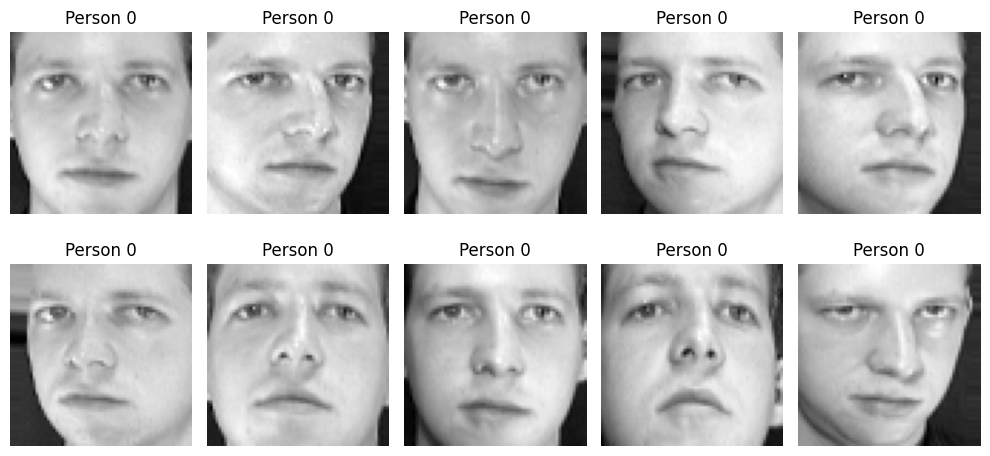

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(f"Person {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (320, 4096)
Testing set: (80, 4096)


In [ ]:
from sklearn.decomposition import PCA

n_components = 100  # try 25, 50, 100, 150

pca = PCA(n_components=n_components, svd_solver="randomized", whiten=True)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original dimension:", X_train.shape[1])
print("Reduced dimension:", X_train_pca.shape[1])

Original dimension: 4096
Reduced dimension: 100


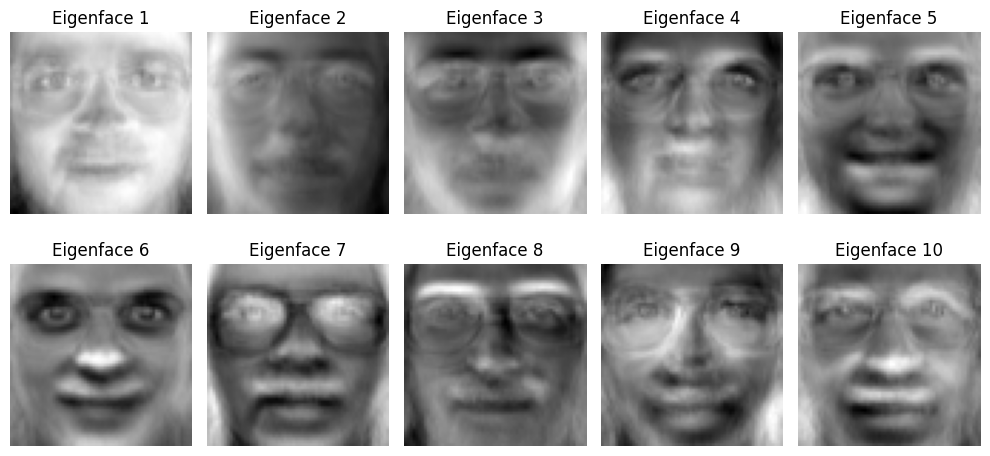

In [ ]:
eigenfaces = pca.components_.reshape((n_components, 64, 64))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i], cmap="gray")
    ax.set_title(f"Eigenface {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca, y_train)

y_pred = knn.predict(X_test_pca)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       1.00      0.50      0.67         2
           2       0.67      1.00      0.80         2
           3       1.00      1.00      1.00         2
           4       0.25      0.50      0.33         2
           5       1.00      1.00      1.00         2
           6       1.00      0.50      0.67         2
           7       1.00      0.50      0.67         2
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       1.00      0.50      0.67         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       0.67      1.00      0.80         2
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
          17

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


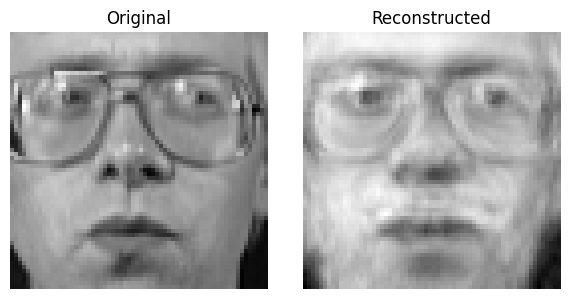

In [ ]:
# Pick one test image
i = 0
original = X_test[i]
projected = pca.transform([original])
reconstructed = pca.inverse_transform(projected)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(original.reshape(64, 64), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(reconstructed.reshape(64, 64), cmap="gray")
axes[1].set_title("Reconstructed")
axes[1].axis("off")

plt.tight_layout()
plt.show()

10 components -> accuracy = 0.8875
20 components -> accuracy = 0.9250
30 components -> accuracy = 0.9375
50 components -> accuracy = 0.9500
75 components -> accuracy = 0.9250
100 components -> accuracy = 0.8625
150 components -> accuracy = 0.8625


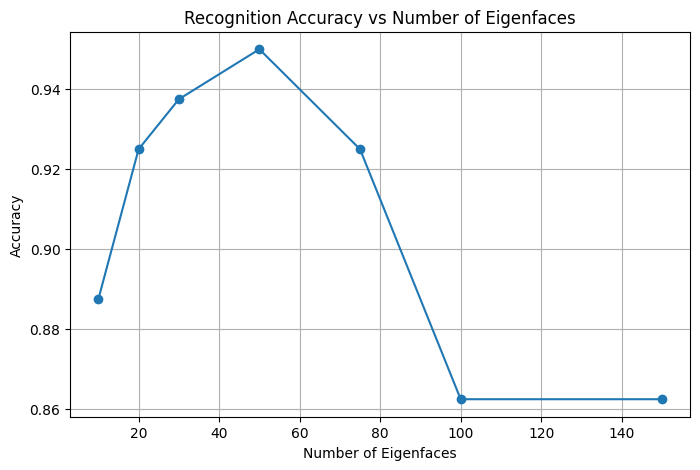

In [ ]:
from sklearn.metrics import accuracy_score

components_list = [10, 20, 30, 50, 75, 100, 150]
accuracies = []

for n in components_list:
    pca = PCA(n_components=n, svd_solver="randomized", whiten=True)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train_pca, y_train)
    y_pred = knn.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"{n} components -> accuracy = {acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(components_list, accuracies, marker="o")
plt.xlabel("Number of Eigenfaces")
plt.ylabel("Accuracy")
plt.title("Recognition Accuracy vs Number of Eigenfaces")
plt.grid(True)
plt.show()